# 03 — Rate Variation Analysis
Payment vs. submitted charges, markup ratio analysis, high-variation procedures, geographic rate spread.

**Inputs:** `data/processed/inpatient_clean.csv`, `data/processed/physician_clean.csv`  
**Outputs:** Figures saved to `figures/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0F0F14',
    'axes.facecolor': '#0F0F14',
    'axes.edgecolor': '#2A2A35',
    'axes.labelcolor': '#E2E0E6',
    'text.color': '#E2E0E6',
    'xtick.color': '#9894A8',
    'ytick.color': '#9894A8',
    'grid.color': '#1E1E28',
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 150
})

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')

INDIGO = '#818CF8'
PINK = '#F472B6'
GREEN = '#10B981'
AMBER = '#F59E0B'
BLUE = '#3B82F6'

---
## 1. Load processed data

In [2]:
inp = pd.read_csv(PROCESSED / 'inpatient_clean.csv', dtype={'provider_zip': str})
print(f'Inpatient: {inp.shape}')

phy = pd.read_csv(
    PROCESSED / 'physician_clean.csv',
    dtype={'provider_zip': str, 'hcpcs_code': str},
    low_memory=False
)
print(f'Physician: {phy.shape}')

Inpatient: (145742, 16)


Physician: (9755020, 24)


---
## 2. Inpatient: charges vs. Medicare payment scatter

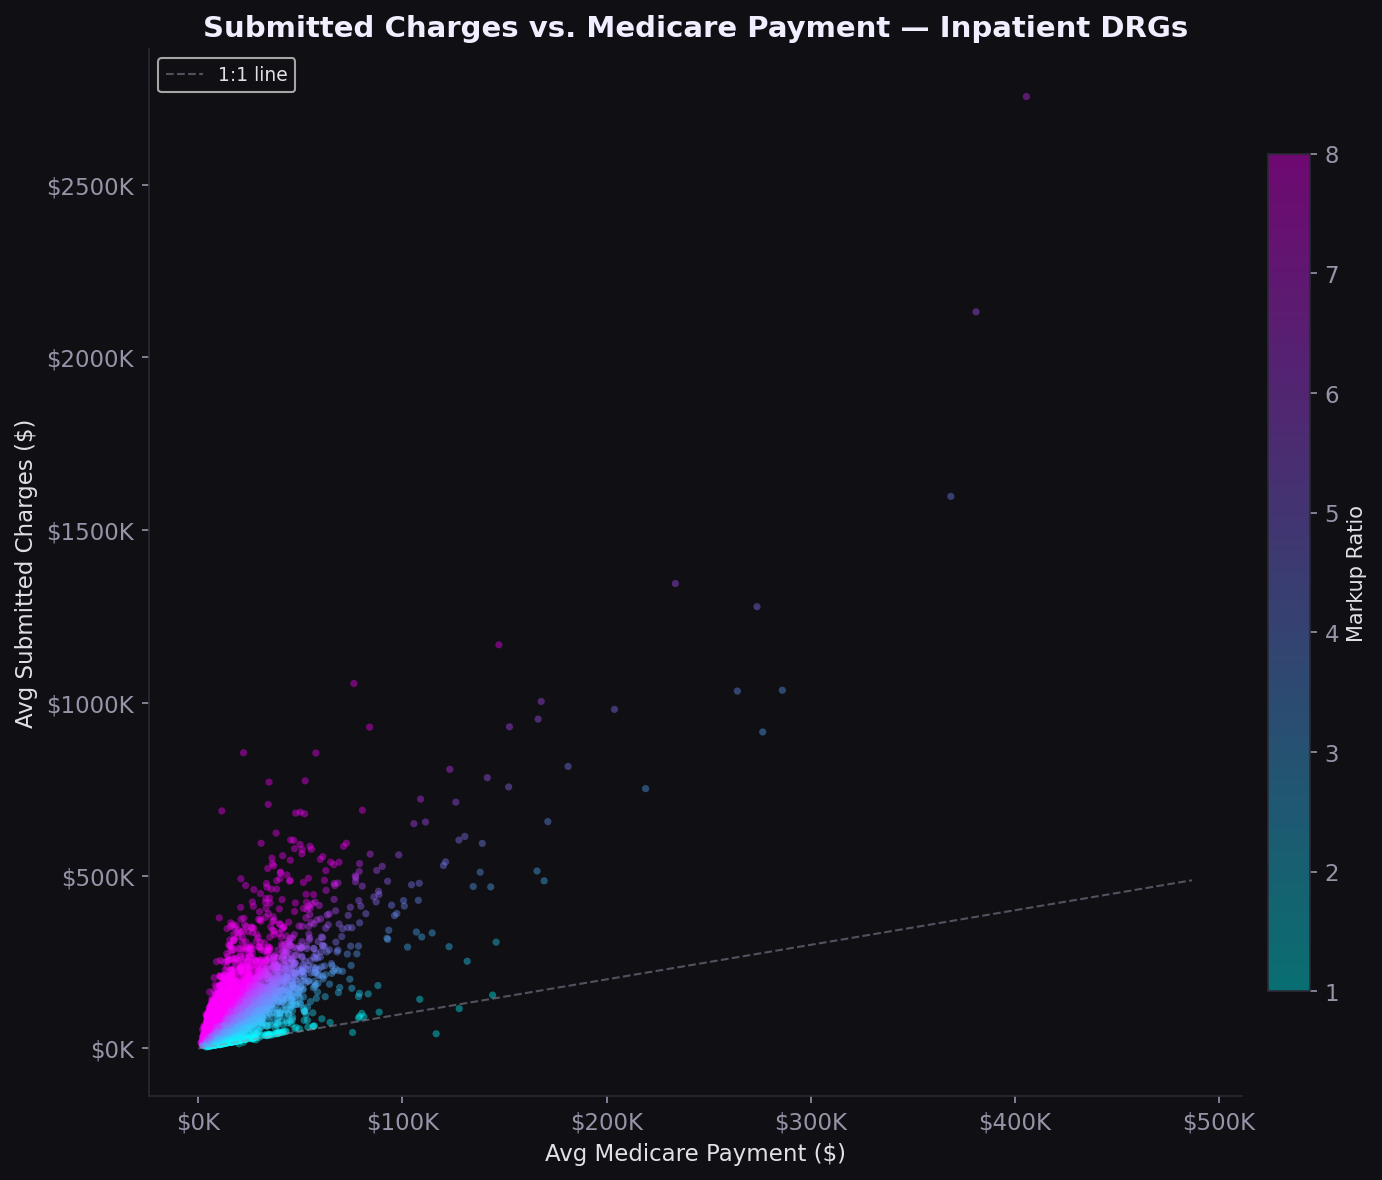

In [3]:
sample = inp.sample(n=min(8000, len(inp)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    sample['avg_medicare_payments'], sample['avg_covered_charges'],
    c=sample['markup_ratio'], cmap='cool', alpha=0.4, s=12,
    vmin=1, vmax=8, edgecolors='none'
)
# 1:1 reference
lim = max(sample['avg_covered_charges'].quantile(0.99), sample['avg_medicare_payments'].quantile(0.99))
ax.plot([0, lim], [0, lim], '--', color='#9894A8', alpha=0.5, linewidth=1, label='1:1 line')

cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Markup Ratio', fontsize=10)

ax.set_xlabel('Avg Medicare Payment ($)')
ax.set_ylabel('Avg Submitted Charges ($)')
ax.set_title('Submitted Charges vs. Medicare Payment — Inpatient DRGs',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'inpatient_charges_vs_payment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Inpatient markup ratio distribution

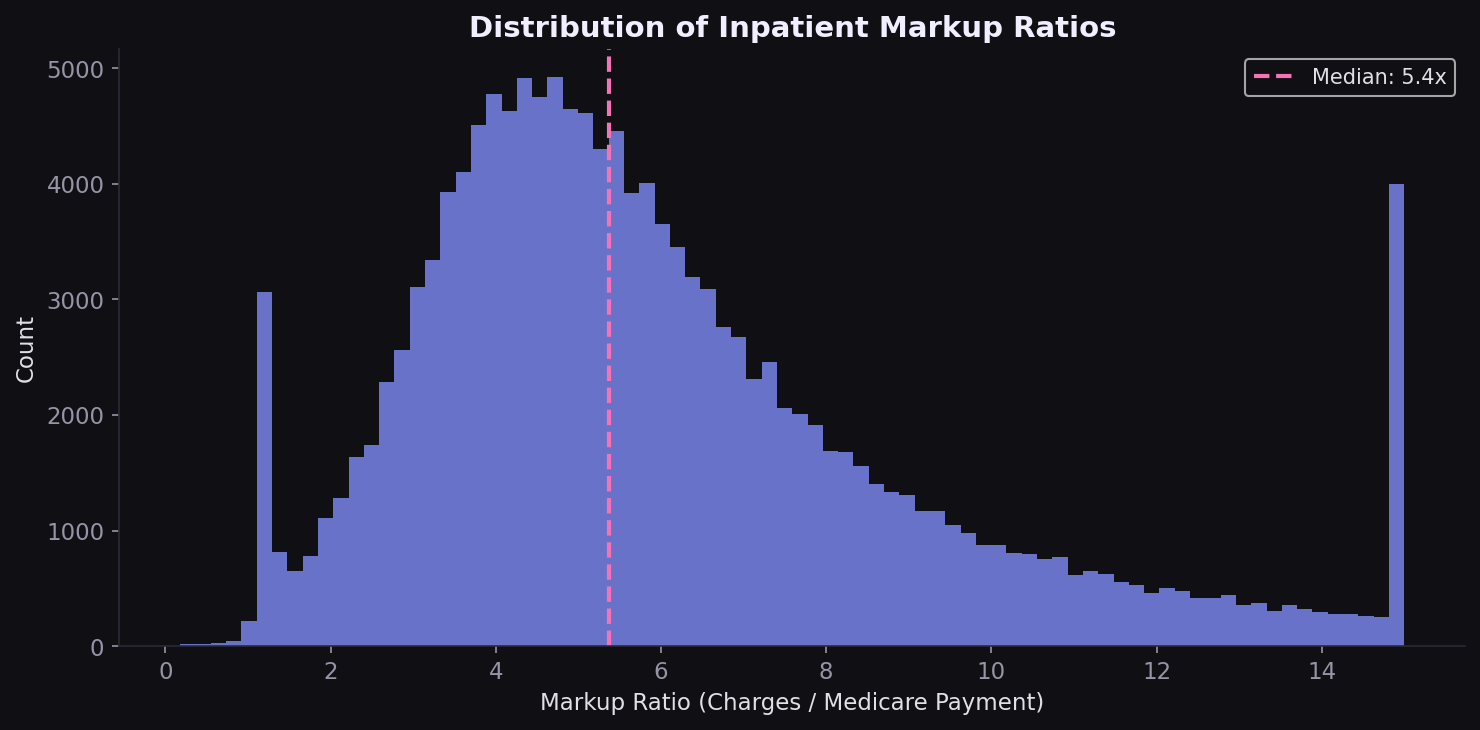

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ratios = inp['markup_ratio'].clip(upper=15)
ax.hist(ratios, bins=80, color=INDIGO, alpha=0.8, edgecolor='none')
median_r = inp['markup_ratio'].median()
ax.axvline(median_r, color=PINK, linewidth=2, linestyle='--', label=f'Median: {median_r:.1f}x')
ax.set_xlabel('Markup Ratio (Charges / Medicare Payment)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Inpatient Markup Ratios', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'inpatient_markup_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Geographic rate spread — inpatient markup by state

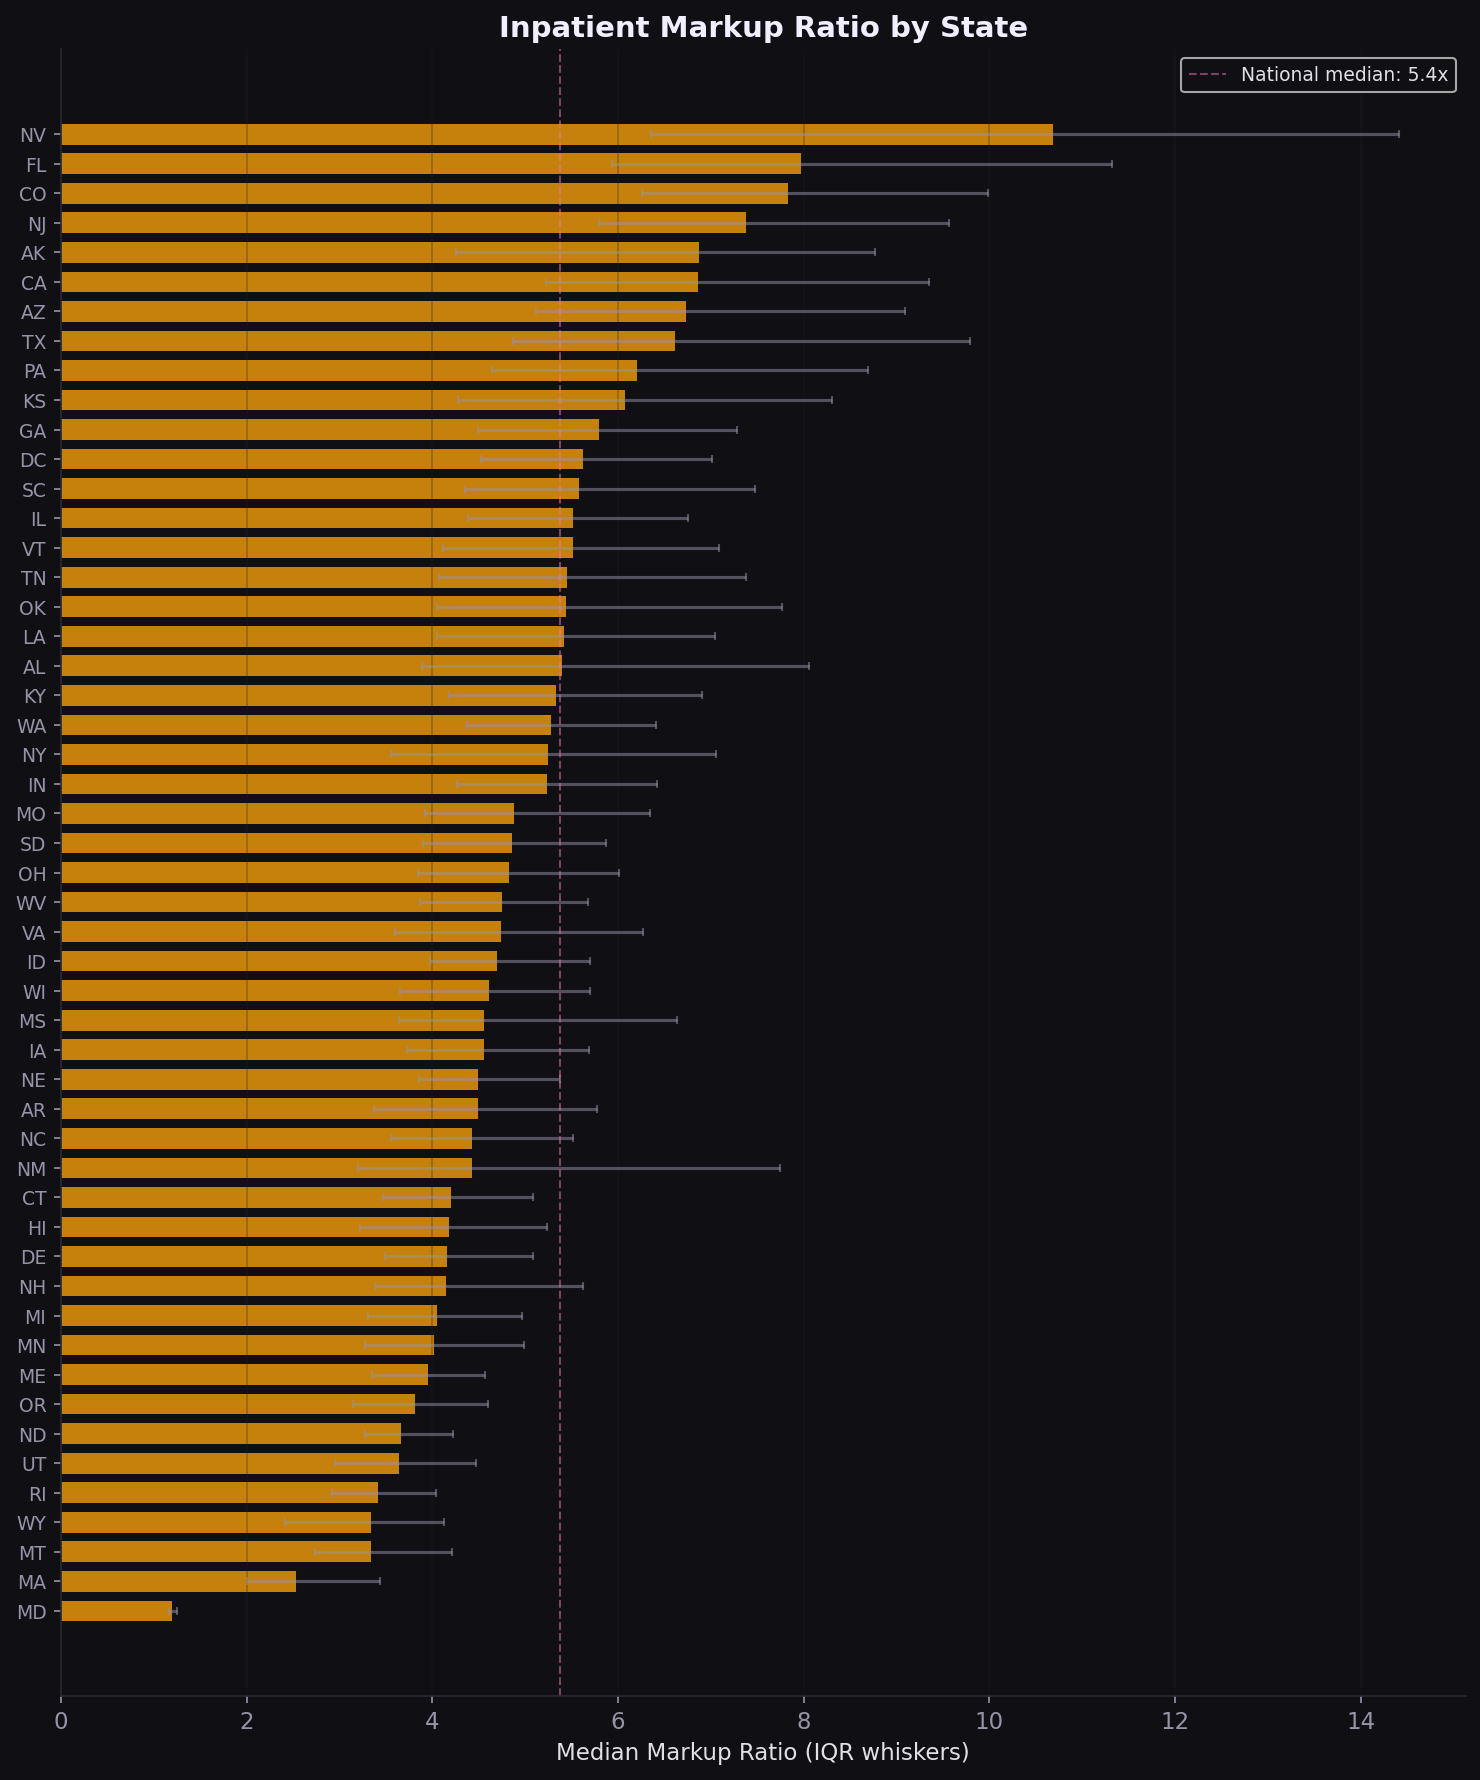

In [5]:
state_markup = (
    inp.groupby('provider_state')
    .agg(
        median_markup=('markup_ratio', 'median'),
        p25=('markup_ratio', lambda x: x.quantile(0.25)),
        p75=('markup_ratio', lambda x: x.quantile(0.75)),
        n=('markup_ratio', 'count')
    )
    .query('n >= 100')
    .sort_values('median_markup', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(state_markup))
ax.barh(y_pos, state_markup['median_markup'], color=AMBER, alpha=0.8, height=0.7)
ax.errorbar(
    state_markup['median_markup'], y_pos,
    xerr=[state_markup['median_markup'] - state_markup['p25'],
          state_markup['p75'] - state_markup['median_markup']],
    fmt='none', color='#9894A8', alpha=0.5, capsize=2
)
ax.set_yticks(y_pos)
ax.set_yticklabels(state_markup.index, fontsize=9)
ax.set_xlabel('Median Markup Ratio (IQR whiskers)')
ax.set_title('Inpatient Markup Ratio by State',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.axvline(x=inp['markup_ratio'].median(), color=PINK, linestyle='--', alpha=0.5,
           linewidth=1, label=f'National median: {inp["markup_ratio"].median():.1f}x')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'state_markup_variation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Physician: charges vs. Medicare allowed scatter

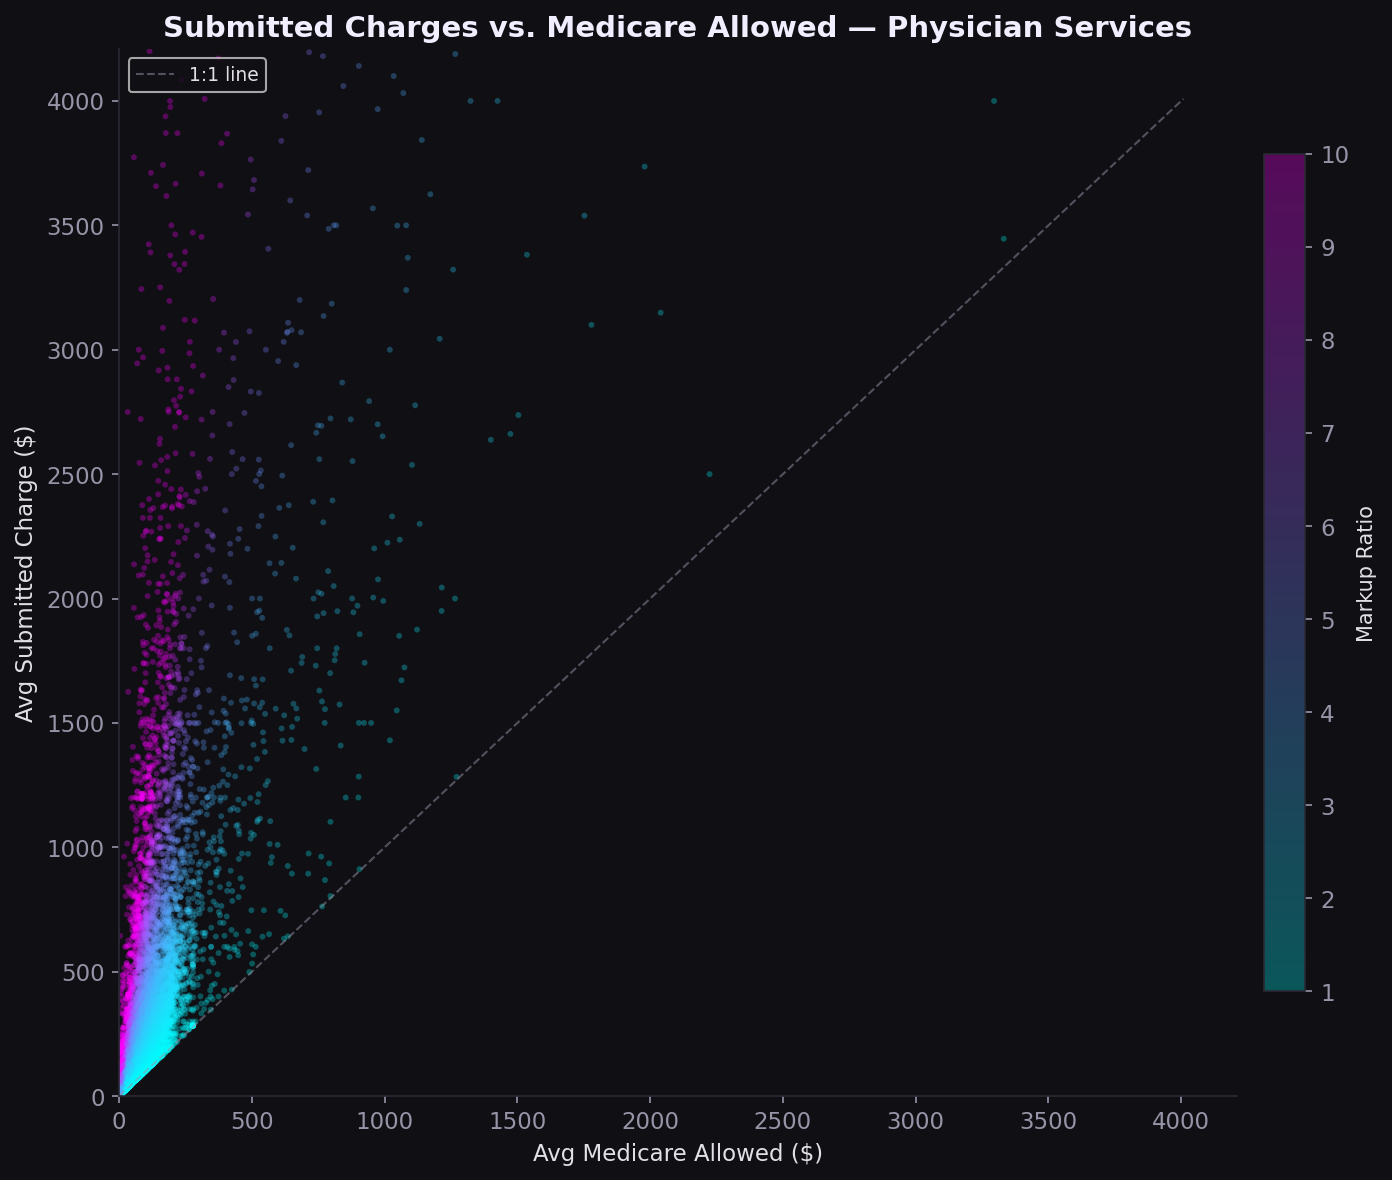

In [6]:
phy_sample = phy.sample(n=15000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    phy_sample['avg_medicare_allowed'], phy_sample['avg_submitted_charge'],
    c=phy_sample['markup_ratio'].clip(upper=10), cmap='cool',
    alpha=0.3, s=8, edgecolors='none', vmin=1, vmax=10
)
lim = max(phy_sample['avg_submitted_charge'].quantile(0.99),
          phy_sample['avg_medicare_allowed'].quantile(0.99))
ax.plot([0, lim], [0, lim], '--', color='#9894A8', alpha=0.5, linewidth=1, label='1:1 line')

cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Markup Ratio', fontsize=10)

ax.set_xlabel('Avg Medicare Allowed ($)')
ax.set_ylabel('Avg Submitted Charge ($)')
ax.set_title('Submitted Charges vs. Medicare Allowed — Physician Services',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.set_xlim(0, lim * 1.05)
ax.set_ylim(0, lim * 1.05)
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'physician_charges_vs_allowed.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Physician: highest-variation HCPCS codes

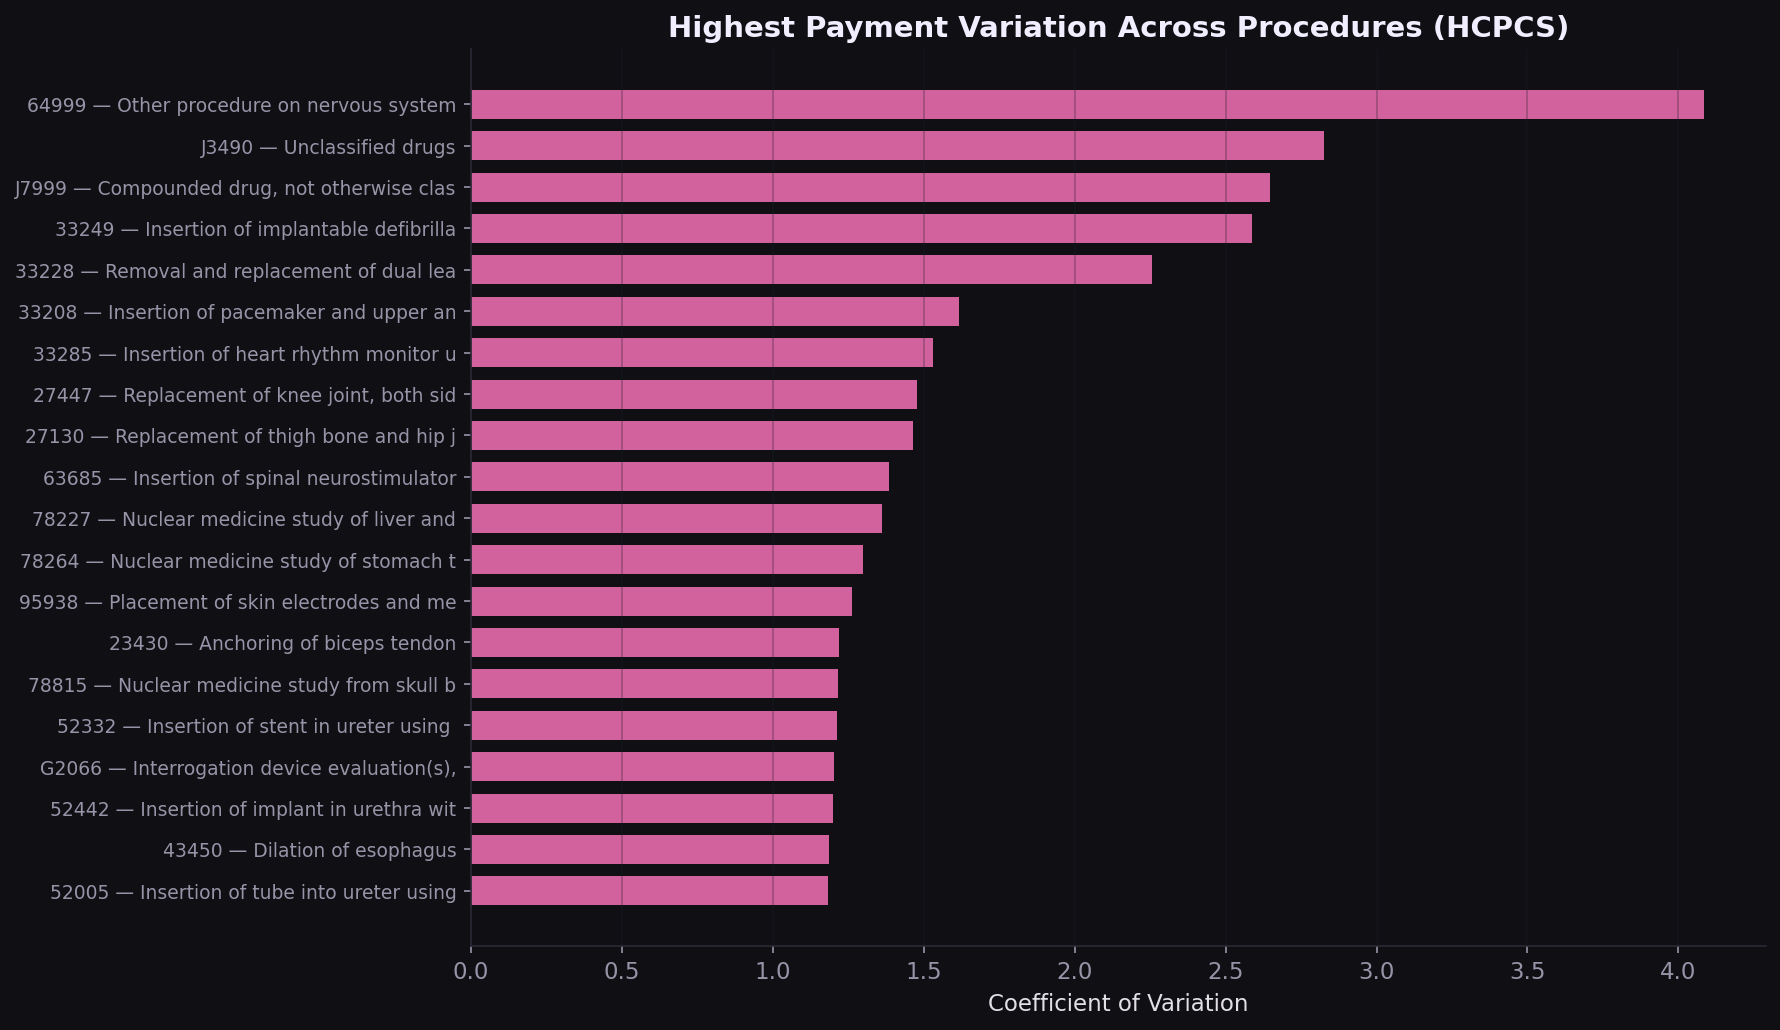

In [7]:
hcpcs_var = (
    phy.groupby(['hcpcs_code', 'hcpcs_desc'])
    .agg(
        cv=('avg_medicare_payment', lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan),
        mean_pay=('avg_medicare_payment', 'mean'),
        n=('avg_medicare_payment', 'count')
    )
    .query('n >= 500 and mean_pay >= 50')
    .sort_values('cv', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{r['hcpcs_code']} — {r['hcpcs_desc'][:35]}" for _, r in hcpcs_var.iterrows()]
bars = ax.barh(range(len(hcpcs_var)), hcpcs_var['cv'], color=PINK, alpha=0.85, height=0.7)
ax.set_yticks(range(len(hcpcs_var)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Coefficient of Variation')
ax.set_title('Highest Payment Variation Across Procedures (HCPCS)',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'hcpcs_payment_variation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Physician: markup ratio by specialty

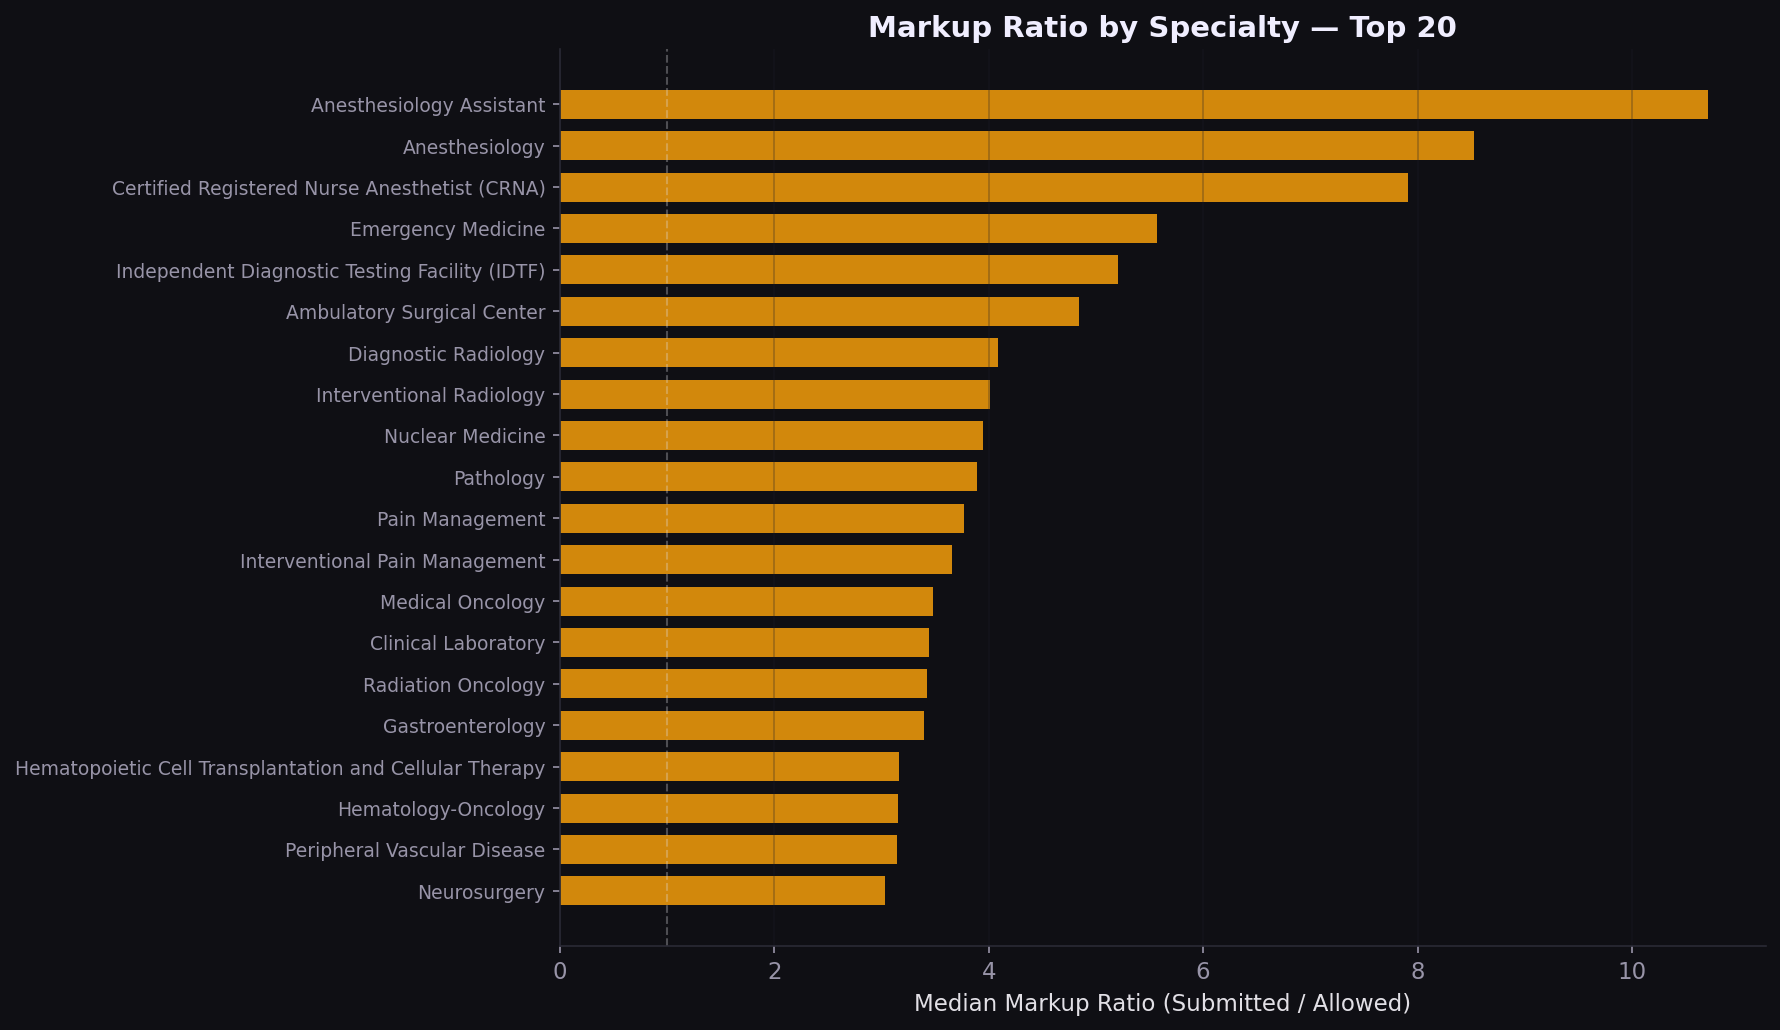

In [8]:
spec_markup = (
    phy.groupby('provider_type')
    .agg(
        median_markup=('markup_ratio', 'median'),
        n=('markup_ratio', 'count')
    )
    .query('n >= 1000')
    .sort_values('median_markup', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [AMBER if v > 3 else INDIGO for v in spec_markup['median_markup']]
ax.barh(range(len(spec_markup)), spec_markup['median_markup'], color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(spec_markup)))
ax.set_yticklabels(spec_markup.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Median Markup Ratio (Submitted / Allowed)')
ax.set_title('Markup Ratio by Specialty — Top 20',
             fontsize=14, fontweight='bold', color='#F0EEFF')
ax.axvline(x=1, color='#E2E0E6', linestyle='--', alpha=0.3, linewidth=1)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'specialty_markup_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Geographic rate spread — physician avg payment by state

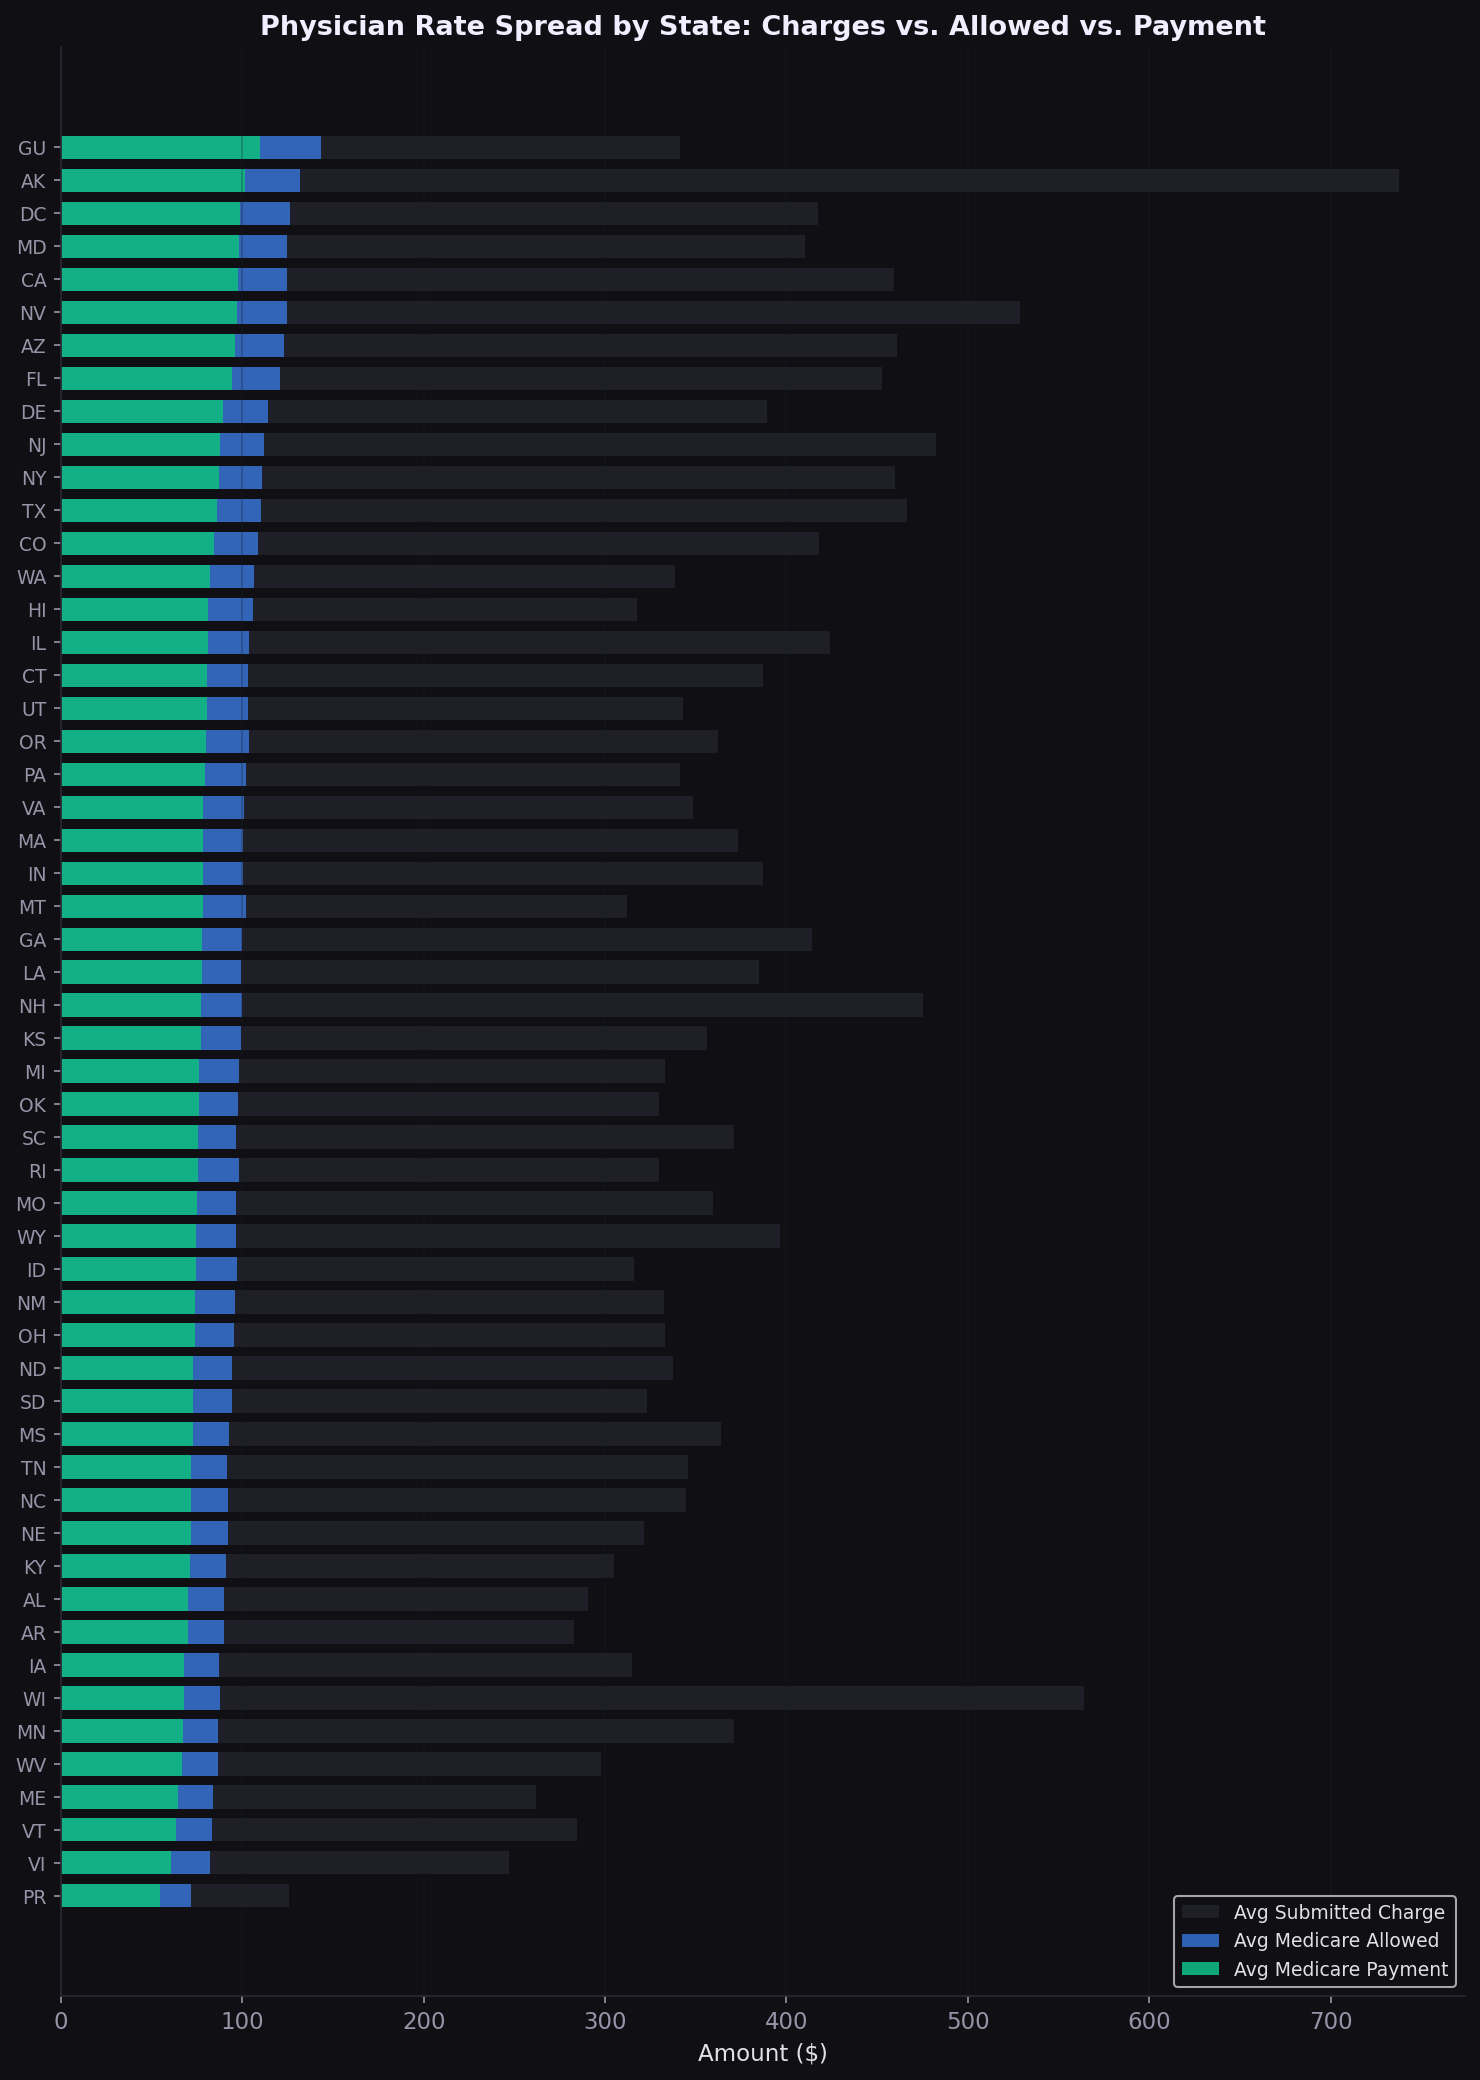

In [9]:
state_phy = (
    phy.groupby('provider_state')
    .agg(
        avg_pay=('avg_medicare_payment', 'mean'),
        avg_allowed=('avg_medicare_allowed', 'mean'),
        avg_charge=('avg_submitted_charge', 'mean'),
        n=('avg_medicare_payment', 'count')
    )
    .query('n >= 1000')
    .sort_values('avg_pay', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 14))
y_pos = range(len(state_phy))

ax.barh(y_pos, state_phy['avg_charge'], color='#2A2A35', alpha=0.6, height=0.7, label='Avg Submitted Charge')
ax.barh(y_pos, state_phy['avg_allowed'], color=BLUE, alpha=0.7, height=0.7, label='Avg Medicare Allowed')
ax.barh(y_pos, state_phy['avg_pay'], color=GREEN, alpha=0.9, height=0.7, label='Avg Medicare Payment')

ax.set_yticks(y_pos)
ax.set_yticklabels(state_phy.index, fontsize=9)
ax.set_xlabel('Amount ($)')
ax.set_title('Physician Rate Spread by State: Charges vs. Allowed vs. Payment',
             fontsize=13, fontweight='bold', color='#F0EEFF')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'state_physician_rate_spread.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary
| Figure | File |
|--------|------|
| Inpatient charges vs payment scatter | `inpatient_charges_vs_payment.png` |
| Inpatient markup distribution | `inpatient_markup_distribution.png` |
| Inpatient markup by state | `state_markup_variation.png` |
| Physician charges vs allowed scatter | `physician_charges_vs_allowed.png` |
| Highest-variation HCPCS codes | `hcpcs_payment_variation.png` |
| Markup ratio by specialty | `specialty_markup_ratio.png` |
| Physician rate spread by state | `state_physician_rate_spread.png` |